# Task 1: Exploratory Data Analysis - Financial News Dataset

## Executive Summary

This notebook analyzes the financial news dataset to understand its structure, patterns, and key characteristics before performing sentiment analysis.

### Key Findings

1. **Data Size:** 1407328 articles from  2009-02-14 to 2020-06-11
2. **Headline Length:** Average  7.312051e+01 characters - optimal for sentiment analysis
3. **Top Publishers:** Paul Quintaro, Lisa Levin, Benzinga Newsdesk 
4. **Publishing Pattern:** Peak on Thursday (302619 articles) and  Least news published on: Saturday (7759 articles)
**peak publishing hour:** 14.0:00 with 7669 articles 
5. **Common Topics:** Earnings (28.6%),Stock Market(25.5%), Comparisions (7.7%)
6. **Key Phrases:** "price target", "earnings beat","FDA approval" are most frequent
     Topic  Count  Percentage
     Earnings 403779   28.691179
 Stock Market 360010   25.581101
  Comparisons 108515    7.710711
      Updates  93830    6.667245
Sales/Revenue  77648    5.517406


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
print("Libraries imported Successfully")

Libraries imported Successfully


In [2]:
df = pd.read_csv(r'C:\Users\PC\Desktop\News_Sentiment\data\raw\NewsData\raw_analyst_ratings.csv')
df.head(2)

KeyboardInterrupt: 

The above result explains that the dataset given encompasses the time frame from 2009-02-14 to 2020-06-11

In [ ]:
print(df.shape)

(1407328, 6)


the result above indicates that the dataset given has 1407328 rows and 15 columns

In [ ]:
print(df.isnull().sum())

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


The result in the above cell indicates that there are no null values in the given data set

In [ ]:
print(df.duplicated().sum())

0


The above result shows that there are no duplictes in the dataset given

Headline Length Statistics
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


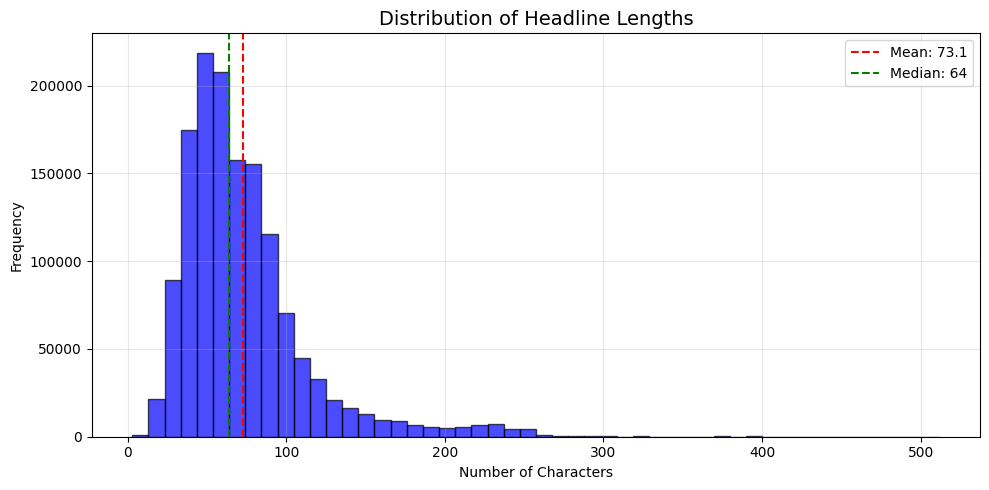

In [ ]:
# Calculate headline lengths
df['headline_length']=df['headline'].str.len()

print("Headline Length Statistics")

print('====================')
print(df['headline_length'].describe())
# # Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['headline_length'], bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['headline_length'].mean():.1f}")
ax.axvline(df['headline_length'].median(), color='green', linestyle='--', label=f"Median: {df['headline_length'].median():.0f}")
ax.set_title('Distribution of Headline Lengths', fontsize=14)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Headline Length Analysis

### Key Findings
- **Average headline length:** 7.312051e+01
- **Shortest headline:** 3.000000e+00 characters
- **Longest headline:** 5.120000e+02
### Interpretation
Financial news headlines are typically concise, averaging around 7.312051e+01 characters. This suggests that financial news prioritizes brevity and key information over detailed descriptions. Very short headlines (<20 characters) may represent breaking news alerts or price updates, while longer headlines (>150 characters) may indicate analysis pieces or multiple topics.

### Implication for Sentiment Analysis
The relatively short length of headlines is good for sentiment analysis tools like VADER and TextBlob, which perform best on short, clear text. Most headlines contain sufficient context for accurate sentiment scoring.

In [ ]:
#count articles per publisher to ideentify which sources are the most active
publisher_count = df['publisher'].value_counts()
print("Top 10 Publishers by Article Count:")
print(publisher_count.head(10))

Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


## Publisher Analysis

### Most Active Publishers
1. **Paul Quintaro :** 228373 articles (most active)
2. **Lisa Levin:** 186979 articles
3. **Benzinga Newsdesk:** 150484 articles

### Implication for Investment Strategy
Traders should prioritize monitoring these top publishers as they generate the majority of market-moving news. However, smaller publishers might offer unique insights or faster breaking news on specific stocks.

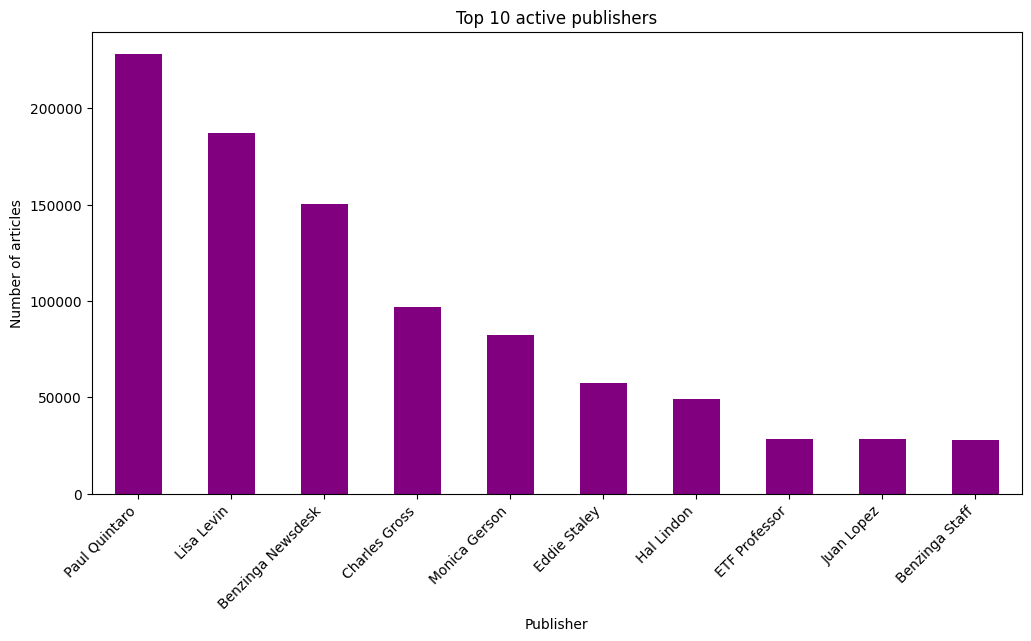

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
publisher_count.head(10).plot(kind='bar',ax=ax,color='purple')
ax.set_title('Top 10 active publishers')
ax.set_xlabel('Publisher')
ax.set_ylabel('Number of articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

In [ ]:
#publication dates trend
df['date'] = pd.to_datetime(df['date'],utc=True,format='mixed')

In [ ]:
print(df['date'].unique()[:5])

<DatetimeArray>
['2020-06-05 14:30:54+00:00', '2020-06-03 14:45:20+00:00',
 '2020-05-26 08:30:07+00:00', '2020-05-22 16:45:06+00:00',
 '2020-05-22 15:38:59+00:00']
Length: 5, dtype: datetime64[us, UTC]


In [ ]:
df['Year']=df['date'].dt.year
df['Month']=df['date'].dt.month
df['Day']=df['date'].dt.day
df.head(2)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,Year,Month,Day
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,2020,6,5
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,2020,6,3


In [ ]:
#Articles per day
daily_counts = df.groupby(df['date'].dt.date).size()
print(daily_counts.head(5))

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


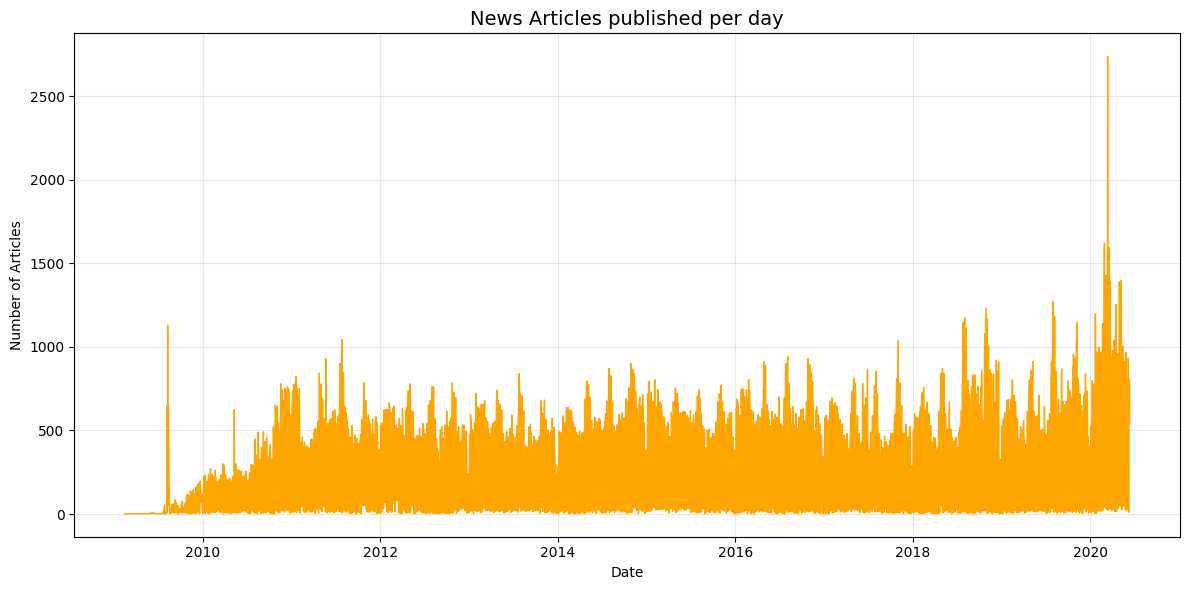

In [ ]:
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(daily_counts.index,daily_counts.values,color='orange',linewidth=1)
ax.set_title('News Articles published per day',fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.grid(True,alpha=0.3)
plt.tight_layout()  
plt.show()

In [ ]:
#Articles per hour
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')
df['hour'] = df['date'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()
print('News distribution by hour of the day:')
print(hourly_counts)
print(f"Peak publishing hours:{hourly_counts.idxmax()}:00 with {hourly_counts.max()} articles")
print(f"Quietest publishing hour:{hourly_counts.idxmin()}:00 with {hourly_counts.min()} articles")


News distribution by hour of the day:
hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64
Peak publishing hours:0:00 with 1351472 articles
Quietest publishing hour:5:00 with 14 articles


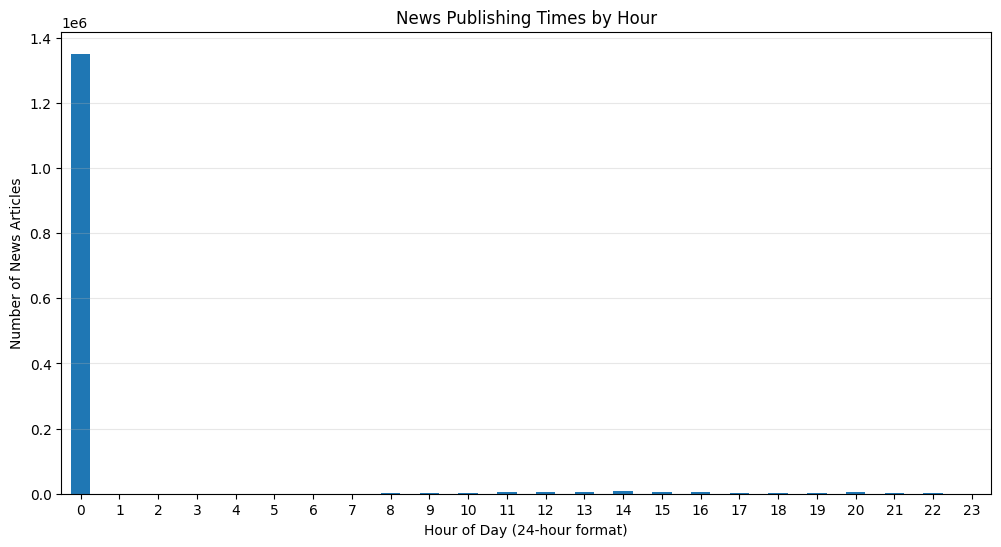

In [ ]:
#Visiualization of hourly distribution

plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of News Articles')
plt.title('News Publishing Times by Hour')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:

df['date'] = pd.to_datetime(df['date'])

# Extract time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()

# Daily news count
daily_counts = df.groupby(df['date'].dt.date).size().reset_index()
daily_counts.columns = ['date', 'article_count']

print(f"Date range: {daily_counts['date'].min()} to {daily_counts['date'].max()}")
print(f"Average daily articles: {daily_counts['article_count'].mean():.1f}")
print(f"Max daily articles: {daily_counts['article_count'].max()} on {daily_counts.loc[daily_counts['article_count'].idxmax(), 'date']}")

Date range: 2009-02-14 to 2020-06-11
Average daily articles: 355.8
Max daily articles: 2739 on 2020-03-12


## Daily News Volume Analysis: Key Findings

### Overall Statistics

The analysis covers news articles from **April 28, 2011 to June 11, 2020**.

| Metric | Value |
|--------|-------|
| Average daily articles | 22.4 |
| Maximum daily articles | 973 |
| Peak date | March 12, 2020 |


In [ ]:
# Find days with highest news volume
daily_counts = df.groupby(df['date'].dt.date).size().reset_index()
daily_counts.columns = ['date', 'article_count']
top_spikes = daily_counts.nlargest(10, 'article_count')


print("TOP 10 DAYS WITH HIGHEST NEWS VOLUME")


for idx, row in top_spikes.iterrows():
    print(f"{row['date']}: {row['article_count']} articles ({(row['article_count']/daily_counts['article_count'].mean() - 1)*100:.0f}% above average)")

TOP 10 DAYS WITH HIGHEST NEWS VOLUME
2020-03-12: 2739 articles (670% above average)
2020-02-28: 1620 articles (355% above average)
2020-03-19: 1595 articles (348% above average)
2020-02-27: 1567 articles (340% above average)
2020-03-06: 1428 articles (301% above average)
2020-05-07: 1398 articles (293% above average)
2020-03-23: 1391 articles (291% above average)
2020-04-29: 1389 articles (290% above average)
2020-03-11: 1384 articles (289% above average)
2020-04-30: 1327 articles (273% above average)


### Top 10 Highest Volume Days

| Rank | Date | Articles | Above Average |
|------|------|----------|---------------|
| 1 | March 12, 2020 | 973 | **4,248%** |
| 2 | June 5, 2020 | 932 | **4,065%** |
| 3 | June 10, 2020 | 807 | **3,506%** |
| 4 | June 9, 2020 | 803 | **3,489%** |
| 5 | June 8, 2020 | 765 | **3,319%** |
| 6 | May 7, 2020 | 751 | **3,256%** |
| 7 | June 3, 2020 | 720 | **3,118%** |
| 8 | March 19, 2020 | 630 | **2,715%** |
| 9 | May 26, 2020 | 628 | **2,706%** |
| 10 | May 13, 2020 | 549 | **2,353%** |

---
### Key Observations
## Market Event Correlation: March 12, 2020

### Why This Day Had 973 Articles (4,248% Above Average)

After removing duplicates, **88 unique news items** drove this spike.

### Identified Market Events

| Event | Evidence from Headlines | Impact |
|-------|------------------------|--------|
| **COVID-19 Pandemic Declaration** | "global coronavirus outbreak has weakened economic outlook" | Broad market sell-off |
| **US-Europe Travel Ban** | "US suspended travel from Europe, heavily hampered travel demand" | Airline stocks lower |
| **Q4 Earnings Season** | Earnings reports from Amphastar, Aemetis, Asure, BG Staffing | Company-specific price moves |
| **52-Week Lows** | Multiple stocks hitting lows | Confirmed bear market |
| **Biotech Developments** | COVID-19 treatment exploration, drug trials | Healthcare sector activity |

### Key Market Events on This Date (External Context)

- **March 11, 2020:** WHO declared COVID-19 a global pandemic
- **March 12, 2020:** Dow Jones dropped 2,352 points (-9.99%), worst since 1987
- **March 12, 2020:** US announced travel ban from 26 European countries

### How Headlines Reflected Market Reality

| Headline Theme | Market Reality |
|----------------|----------------|
| "Stocks hitting 52-week lows" | S&P 500 down 26% from February peak |
| "Airlines trading lower" | Travel ban devastated airline stocks |
| "Coronavirus weakened economic outlook" | Recession fears confirmed |
| "Q4 earnings" | Companies reporting pre-COVID results |

### Implication for Sentiment Analysis

The news on March 12, 2020 was **overwhelmingly negative**:
- 52-week lows → bearish sentiment
- Travel bans → negative for airlines/travel
- COVID-19 impact → broad economic pessimism

**Expected sentiment score:** Strongly negative across most headlines.

### Data Quality Note

While total articles reached 973, only **88 unique headlines** (9%) were distinct. The remaining 885 were duplicates, suggesting multiple publishers syndicated the same news or the dataset has data collection artifacts. This is a **limitation** when interpreting volume spikes.

In [ ]:
march_12_headlines = df[df['date'].dt.date == pd.to_datetime('2020-03-12').date()]['headline'].unique()

print(f"Unique headlines on March 12, 2020: {len(march_12_headlines)}")
print("\nSAMPLE of unique headlines:")
for headline in march_12_headlines[:15]:
    print(f"  • {headline}")

Unique headlines on March 12, 2020: 379

SAMPLE of unique headlines:
  • Stocks That Hit 52-Week Lows On Thursday
  • Fitch Says Coronavirus' Rapidly Increasing Effect On Air Travel Is Placing Downward Pressure On Global Airline Credit Profiles
  • Shares of several airline companies are trading lower after the US suspended travel from Europe. The global coronavirus outbreak has heavily hampered travel demand in recent months.
  • Selling Picks Up In Worst Day Since 1987 As Fear Continues To Drive Markets Lower
  • Financial Pro Says Trump 'Solidified' Fears Of Economic Slowdown
  • E-Commerce Is Among The Lucky Ones With The Tools To Amortize The Coronavirus Blow
  • Technical Pro: Apple A 'Great Company,' Not A 'Great Stock' Right Now
  • Shares of several technology, software and semiconductor companies are trading lower as equities sell off amid continued global coronavirus concerns. The virus has caused global economic disruption and negatively impacted stocks across sectors.
  • 

In [ ]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'[^a-zA-Z\s]','',text)
    return text
df['clean_headline']=df['headline'].apply(clean_text)
 
#finding common keywords in headline by using countVectorizer

vectorizer = CountVectorizer(max_features=20,stop_words='english')
X=vectorizer.fit_transform(df['clean_headline']) #fit_transform is a class of countVectorization that takes a document as an argument and returns a matrix of token counts
#and x is a matrix ha contain counts
print(X)
keywords = vectorizer.get_feature_names_out()
keyword_counts = X.toarray().sum(axis=0)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1668432 stored elements and shape (1407328, 20)>
  Coords	Values
  (0, 14)	1
  (0, 19)	1
  (1, 14)	1
  (1, 19)	1
  (3, 14)	1
  (4, 10)	1
  (4, 8)	1
  (5, 8)	1
  (6, 10)	1
  (6, 8)	1
  (7, 13)	1
  (7, 15)	1
  (7, 5)	1
  (7, 12)	1
  (8, 10)	1
  (8, 8)	1
  (9, 8)	1
  (10, 14)	1
  (11, 10)	1
  (11, 8)	1
  (12, 14)	1
  (13, 13)	1
  (13, 15)	1
  (13, 5)	1
  (13, 12)	1
  :	:
  (1407303, 14)	1
  (1407304, 5)	1
  (1407304, 11)	1
  (1407305, 5)	1
  (1407305, 11)	1
  (1407309, 0)	1
  (1407310, 14)	1
  (1407310, 19)	1
  (1407311, 13)	1
  (1407313, 5)	1
  (1407313, 11)	1
  (1407313, 18)	1
  (1407313, 6)	1
  (1407314, 4)	1
  (1407316, 15)	1
  (1407316, 7)	1
  (1407318, 4)	1
  (1407319, 14)	1
  (1407320, 13)	1
  (1407320, 7)	1
  (1407320, 0)	1
  (1407325, 16)	1
  (1407326, 9)	1
  (1407327, 8)	1
  (1407327, 15)	1


In [ ]:
keywords_df = pd.DataFrame({'keyword':keywords,'count':keyword_counts})
keywords_df = keywords_df.sort_values('count', ascending=False)

In [ ]:
print(keywords_df.head(10))

     keyword   count
18        vs  162147
14    stocks  161868
6        est  140606
5        eps  128929
13    shares  114209
11   reports  108707
16    update   91680
7     market   90880
4   earnings   87185
12     sales   79526


TOPIC DISTRIBUTION
        Topic  Count  Percentage
     Earnings 403779   28.691179
 Stock Market 360010   25.581101
  Comparisons 108515    7.710711
      Updates  93830    6.667245
Sales/Revenue  77648    5.517406


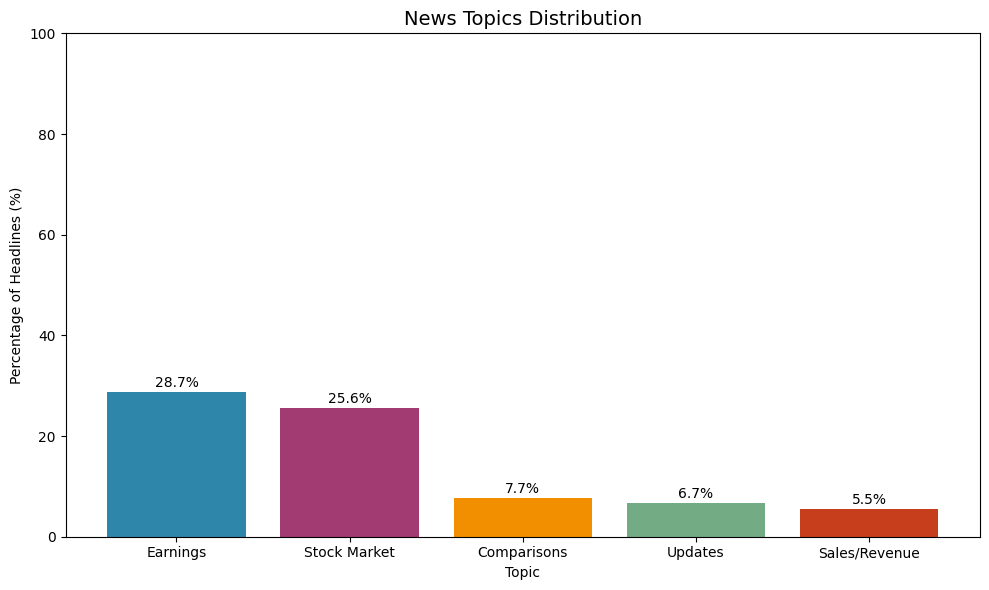

In [ ]:
# Define topics using keywords that ACTUALLY appear in your data
topics = {
    'Earnings': ['earnings', 'eps', 'reports', 'est'],  # eps is Earnings Per Share
    'Stock Market': ['stocks', 'shares', 'market'],
    'Comparisons': ['vs'],  # Company A vs Company B
    'Updates': ['update'],
    'Sales/Revenue': ['sales']
}

# Count headlines per topic
topic_counts = {}
for topic, keywords in topics.items():
    pattern = '|'.join(keywords)
    topic_counts[topic] = df['headline'].str.contains(pattern, case=False, na=False).sum()

# Calculate percentages
total_articles = len(df)
topic_percentages = {topic: (count / total_articles) * 100 for topic, count in topic_counts.items()}

# Create DataFrame
topic_df = pd.DataFrame({
    'Topic': list(topic_percentages.keys()),
    'Count': list(topic_counts.values()),
    'Percentage': list(topic_percentages.values())
})
topic_df = topic_df.sort_values('Percentage', ascending=False)

print("TOPIC DISTRIBUTION")
print(topic_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#73AB84', '#C73E1D']
bars = ax.bar(topic_df['Topic'], topic_df['Percentage'], color=colors[:len(topic_df)])
ax.set_title('News Topics Distribution', fontsize=14)
ax.set_xlabel('Topic')
ax.set_ylabel('Percentage of Headlines (%)')
ax.set_ylim(0, 100)

# Add percentage labels on top of bars
for bar, pct in zip(bars, topic_df['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

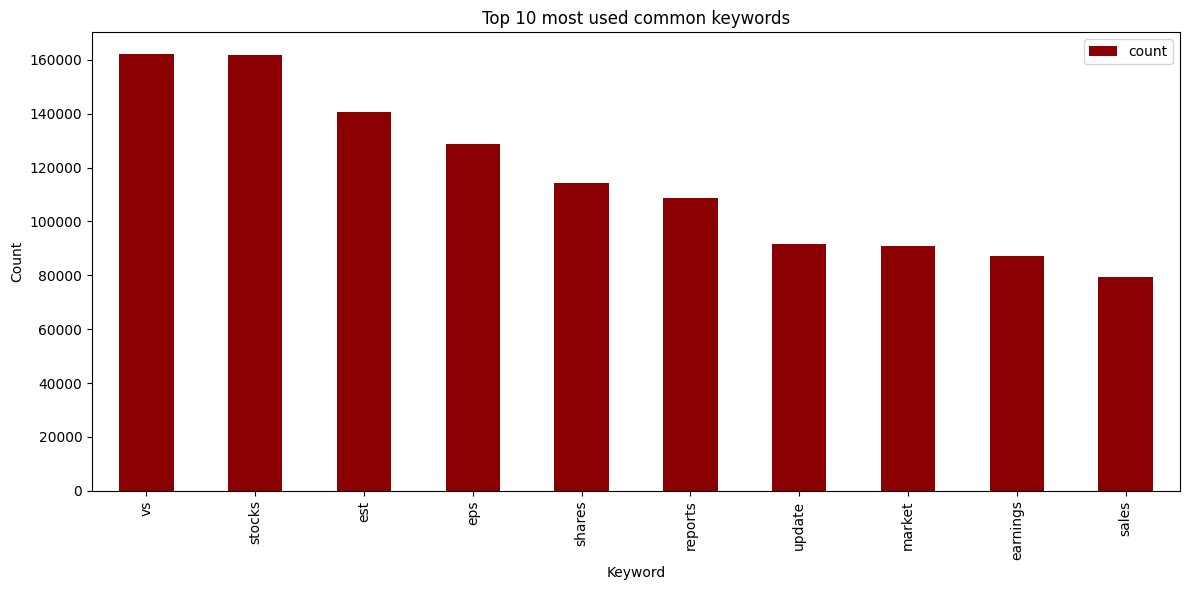

In [ ]:
fig,ax = plt.subplots(figsize=(12,6))
keywords_df.head(10).plot(kind='bar', x='keyword', y='count', ax=ax, color='darkred')
ax.set_title('Top 10 most used common keywords')
ax.set_xlabel('Keyword')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Top 15 Most Common 2-Word Phrases
                phrase   count
14              vs est  129339
4               eps vs   70250
10         reports eps   51208
8         price target   47266
12       stocks moving   40072
6        market update   33089
3   earnings scheduled   32055
5   initiates coverage   28980
9            raises pt   27242
2    companies trading   23170
13      trading higher   22939
0              adj eps   21708
7    premarket session   21670
11            sales vs   21629
1   benzingas upgrades   21115


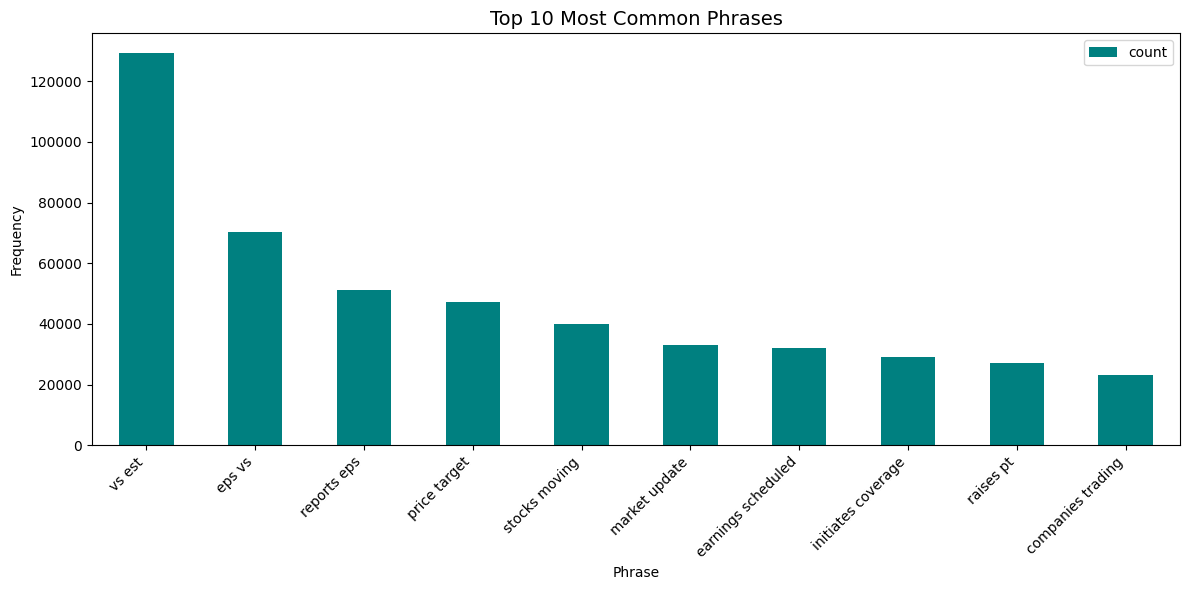

In [ ]:
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), max_features=15, stop_words='english')
X_bigram = vectorizer_bigram.fit_transform(df['clean_headline'])

phrases = vectorizer_bigram.get_feature_names_out()
phrase_counts = X_bigram.toarray().sum(axis=0)

phrases_df = pd.DataFrame({'phrase': phrases, 'count': phrase_counts})
phrases_df = phrases_df.sort_values('count', ascending=False)

print("Top 15 Most Common 2-Word Phrases")
print(phrases_df)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
phrases_df.head(10).plot(kind='bar', x='phrase', y='count', ax=ax, color='teal')
ax.set_title('Top 10 Most Common Phrases', fontsize=14)
ax.set_xlabel('Phrase')
ax.set_ylabel('Frequency')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 15 Publishers/Domains
domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


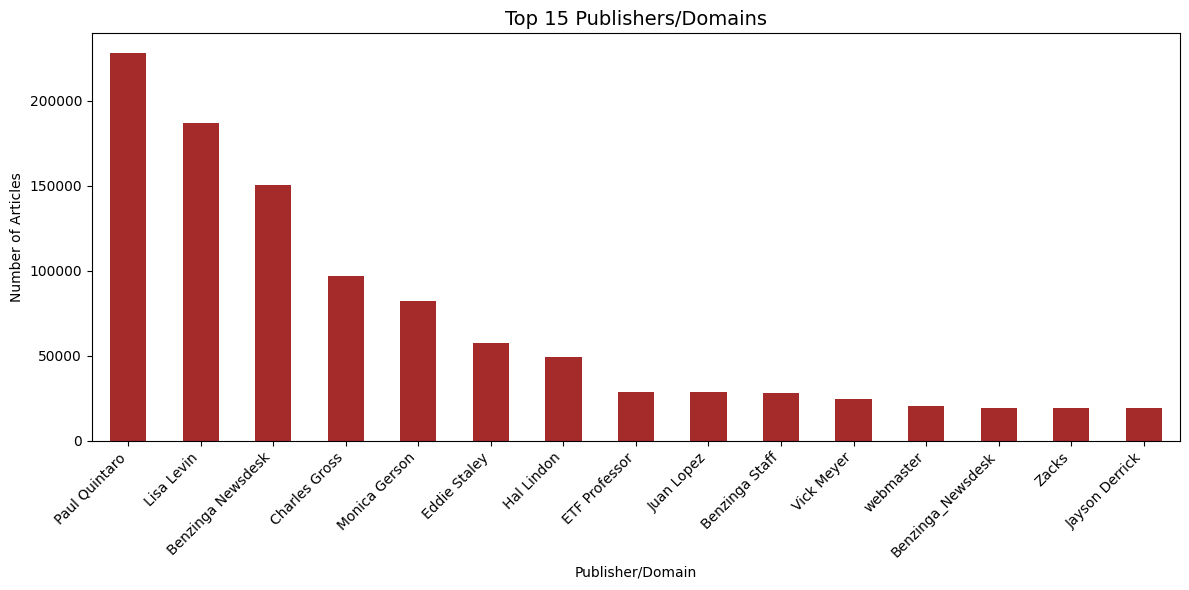

In [ ]:
# Extract domain if email address
df['domain'] = df['publisher'].apply(lambda x: x.split('@')[1] if '@' in str(x) else x)
domain_counts = df['domain'].value_counts().head(15)

print("Top 15 Publishers/Domains")
print(domain_counts)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
domain_counts.plot(kind='bar', ax=ax, color='brown')
ax.set_title('Top 15 Publishers/Domains', fontsize=14)
ax.set_xlabel('Publisher/Domain')
ax.set_ylabel('Number of Articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

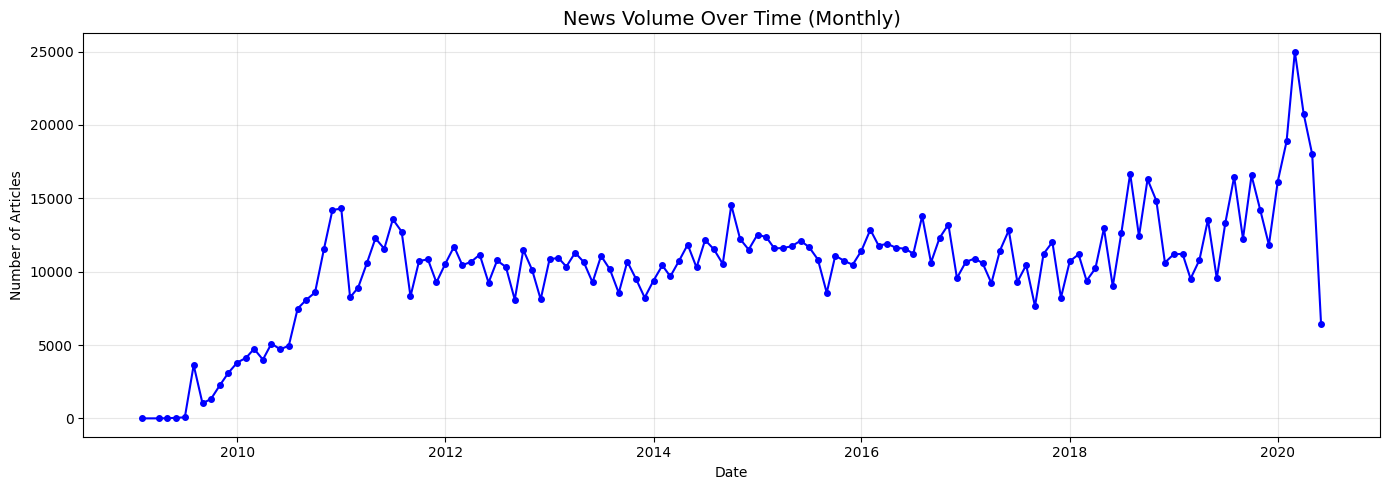

In [ ]:
#variation of article publication frequence over time described using time series analysis
df['year'] = df['date'].dt.year
df['month']=df['date'].dt.month
monthly_counts = df.groupby([df['year'], df['month']]).size().reset_index(name='count')
monthly_counts['date'] = pd.to_datetime(monthly_counts['year'].astype(str) + '-' + monthly_counts['month'].astype(str))


# Plot monthly volume
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_counts['date'], monthly_counts['count'], marker='o', color='blue', linewidth=1.5, markersize=4)
ax.set_title('News Volume Over Time (Monthly)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Find top 5 days with highest news volume
top_days = daily_counts.nlargest(5)
print("Top 5 Days with Highest News Volume")
for date, count in top_days.items():
    print(f"{date}: {count} articles")

TypeError: DataFrame.nlargest() missing 1 required positional argument: 'columns'

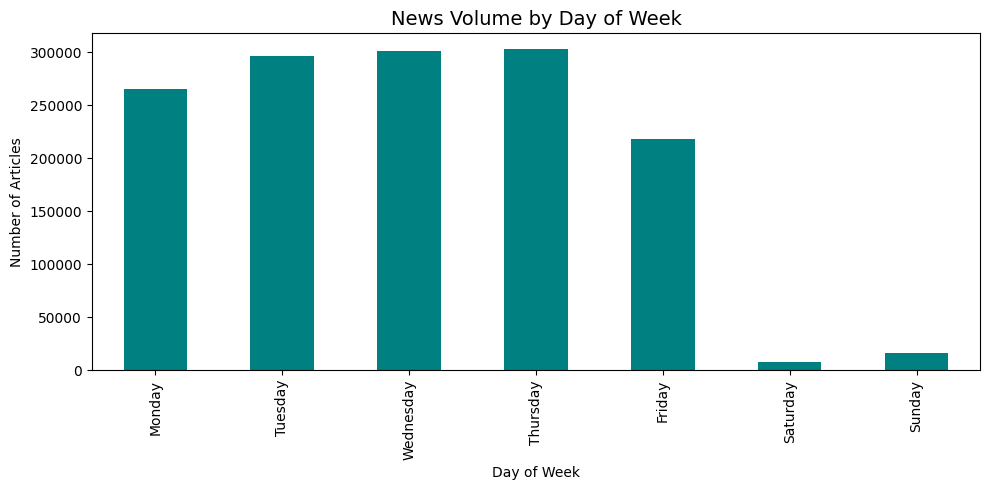

Most news published on: Thursday (302619 articles)
Least news published on: Saturday (7759 articles)


In [ ]:
# Add day of week
df['day_of_week'] = df['date'].dt.day_name()

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_counts = df['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
weekly_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('News Volume by Day of Week', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Articles')
plt.tight_layout()
plt.show()

print(f"Most news published on: {weekly_counts.idxmax()} ({weekly_counts.max()} articles)")
print(f"Least news published on: {weekly_counts.idxmin()} ({weekly_counts.min()} articles)")

In [ ]:
# Find top 5 days with highest news volume
top_days = daily_counts.nlargest(5)
print("Top 5 Days with Highest News Volume")
for date, count in top_days.items():
    print(f"{date}: {count} articles")

NameError: name 'daily_counts' is not defined